<a href="https://colab.research.google.com/github/benoitmialet/artificial_neural_networks_labs/blob/main/ann_lab_03_housing_regression_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Solving a regression problem (California Housing dataset) with Neural Networks using `PyTorch`


In this lab we will build a neural network to solve a regression problem. We want to predict the price of a house, given the caracteristics of the location.

We will have the same approach as during the previous lab, but we will add some new features in ours code to improve it:
* **Device agnostic code**, that can automatically adapt to the device (cpu or gpu) or the system
* **Evaluation method**, that we will add in our training loop, to have a better assessment of model performance.
* **Tensorboard logging**, a nice vizualisation tool that can also store training metrics


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

RANDOM_STATE = 101
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

## Load California housing dataset and observe data

In [5]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
print(housing.data.shape, housing.target.shape)
print(housing.feature_names)

(20640, 8) (20640,)
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


### With `pandas`

`pandas` is not required to work with California Housing dataset as it is already provided by `scikit-learn` in numpy array format (and we want it in numpy format). This is just an example of `pandas` usage.

In [13]:
complete_df = pd.DataFrame(housing.data, columns=housing.feature_names)
complete_df['price'] = housing.target
df = complete_df.sample(n=5000, random_state=RANDOM_STATE)

In [ ]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
20046,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01,0.47700
3024,2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46,0.45800
15663,3.4801,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44,5.00001
20484,5.7376,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72,2.18600
9814,3.7250,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93,2.78000


In [8]:
# sns.pairplot(df)

### with `numpy`

In [9]:
X = housing.data
y = housing.target

print("Features")
print(X[:2])
print(X.shape)
print(X.dtype)
print("Target")
print(y[:2])
print(y.shape)
print(y.dtype)

Features
[[ 8.32520000e+00  4.10000000e+01  6.98412698e+00  1.02380952e+00
   3.22000000e+02  2.55555556e+00  3.78800000e+01 -1.22230000e+02]
 [ 8.30140000e+00  2.10000000e+01  6.23813708e+00  9.71880492e-01
   2.40100000e+03  2.10984183e+00  3.78600000e+01 -1.22220000e+02]]
(20640, 8)
float64
Target
[4.526 3.585]
(20640,)
float64


## Prepare features and target

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
  X,
  y,
  test_size=0.3,
  random_state=RANDOM_STATE
)

print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)


(14448, 8)
(14448,)
(6192, 8)
(6192,)


In [30]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# scaler = MinMaxScaler()
# help(StandardScaler)
scaler = StandardScaler()

In [31]:
scaler.fit(X_train)

StandardScaler()

In [32]:
X_train = scaler.transform(X_train)
X_val = scaler.transform(X_val)

In [33]:
print(X_train.min())
print(X_train.max())

-2.3573369846752223
103.30471397463221


Optional : Loop over features in X_train and plot histogram

In [20]:
# for i in range(X_train.shape[1]):
#     plt.figure(figsize=(8, 6))
#     sns.histplot(data=X_train[:, i], kde=True, bins=30)
#     plt.title(f'Distribution of {housing.feature_names[i]} (Scaled)')
#     plt.xlabel(housing.feature_names[i])
#     plt.ylabel('Frequency')
#     plt.show()

## Build `dataset` & `dataloader`

It's best practice to write [**device agnostic code**](https://pytorch.org/docs/master/notes/cuda.html#device-agnostic-code).

Thus, we first define the device automatically so that this code will adapt to system ressources.

In [21]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [34]:
from torch.utils.data import Dataset, DataLoader, TensorDataset

# Custom Dataset class
class HousingDataset(Dataset):
    def __init__(self, features, targets):
        self.X = torch.tensor(features, dtype=torch.float32)
        self.y = torch.tensor(targets, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create DataLoader
train_dataset = HousingDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Create DataLoader for validation set
val_dataset = HousingDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

## Define the model

In [35]:
import torch.nn as nn
class RegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(8, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 32)
        self.fc4 = nn.Linear(32, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x

In [36]:
# another way to write the model class:
import torch.nn as nn
class RegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.ff = nn.Sequential(
            nn.Linear(8, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.ff(x)

model = RegressionModel()

## Training loop + TensorBoard logging

In [25]:
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm

# Initialize SummaryWriter
writer = SummaryWriter("./runs/housing_regression_nn")

model = RegressionModel().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.RMSprop(model.parameters(), lr=0.00005)

for epoch in tqdm(range(50)):
    model.train()
    epoch_train_loss = 0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        preds = model(x_batch)
        loss = criterion(preds, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
    avg_train_loss = epoch_train_loss / len(train_loader)
    writer.add_scalar('Loss/train', avg_train_loss, epoch)

writer.close()

100%|██████████| 50/50 [00:20<00:00,  2.39it/s]


In [42]:
# On Jupyter Notebbook or vscode:
# tensorboard --logdir=runs  # then go to --> http://localhost:6006

# on Google colab:
%load_ext tensorboard
%tensorboard --logdir "./runs"

## Training loop + evaluation

We are going to build a complete method to evealuate model performance.
In the previous lab, we just computed the validation loss. Now we will add other metrics, easier to interpret for humans: `MAE`, `MSE`, `RMSE`  

In [37]:
def evaluate_regression(model, loader, criterion):
    model.eval()
    epoch_loss = 0
    all_preds, all_targets = [], []

    with torch.inference_mode():
        for x_batch, y_batch in loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            preds = model(x_batch)
            loss = criterion(preds, y_batch)
            epoch_loss += loss.item()

            all_preds.append(preds.squeeze())
            all_targets.append(y_batch.squeeze())

    all_preds = torch.cat(all_preds).cpu().numpy()
    all_targets = torch.cat(all_targets).cpu().numpy()
    avg_loss = epoch_loss / len(loader)

    return avg_loss, all_preds, all_targets

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm

writer = SummaryWriter("./runs/housing_regression_nn")  # this will overwrite any previous run with the same name

model = RegressionModel().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.RMSprop(model.parameters(), lr=0.00005)

for epoch in tqdm(range(50)):
    model.train()
    epoch_train_loss = 0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        preds = model(x_batch)
        loss = criterion(preds, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
    avg_train_loss = epoch_train_loss / len(train_loader)
    writer.add_scalar('Loss/train', avg_train_loss, epoch)

    # Evaluate on validation set using the new method
    avg_val_loss, val_preds, val_trues = evaluate_regression(model, val_loader, criterion)

    # Calculate sklearn metrics
    mae = mean_absolute_error(val_trues, val_preds)
    mse = mean_squared_error(val_trues, val_preds)
    rmse = np.sqrt(mse).item()  # Convert to standard Python float

    # Log metrics to TensorBoard
    writer.add_scalar('Loss/validation', avg_val_loss, epoch)
    writer.add_scalar('Metrics/MAE', mae, epoch)
    writer.add_scalar('Metrics/MSE', mse, epoch)
    writer.add_scalar('Metrics/RMSE', rmse, epoch)


writer.close()

100%|██████████| 50/50 [00:23<00:00,  2.12it/s]


## Evaluate the model with a test dataset

> **Reminder**: We do not have any test set here, so we will use `val_loader` for course convenience. In real life, never use a validation set to perform the final evaluation of the model.

Test Loss (MSE): 0.5513
Test MAE: 0.4211
Test MSE: 0.5517
Test RMSE: 0.7427


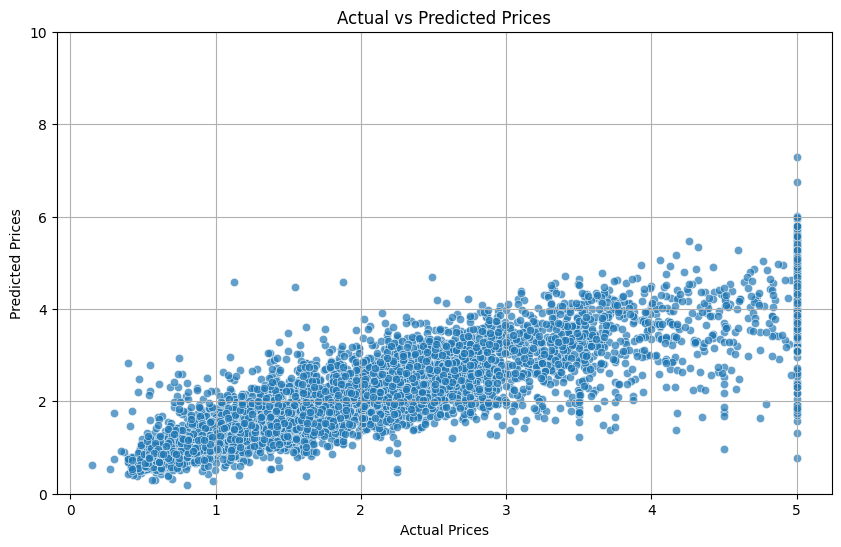

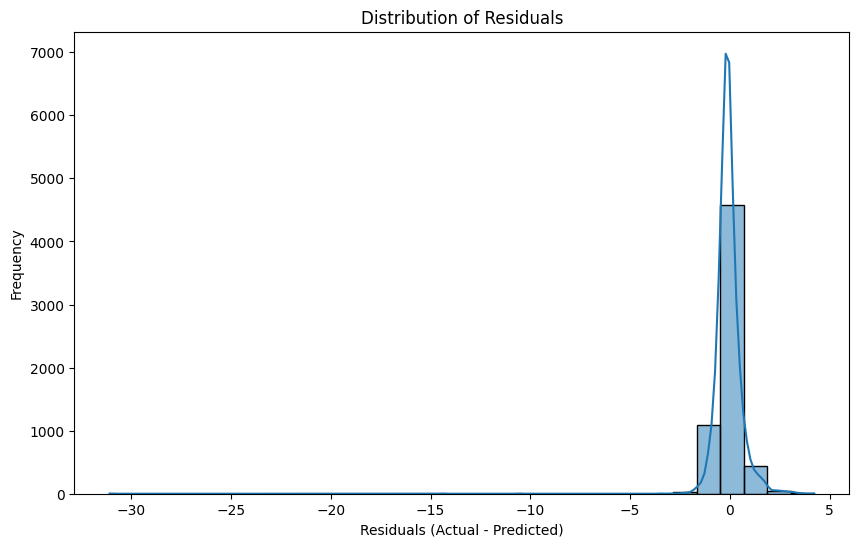

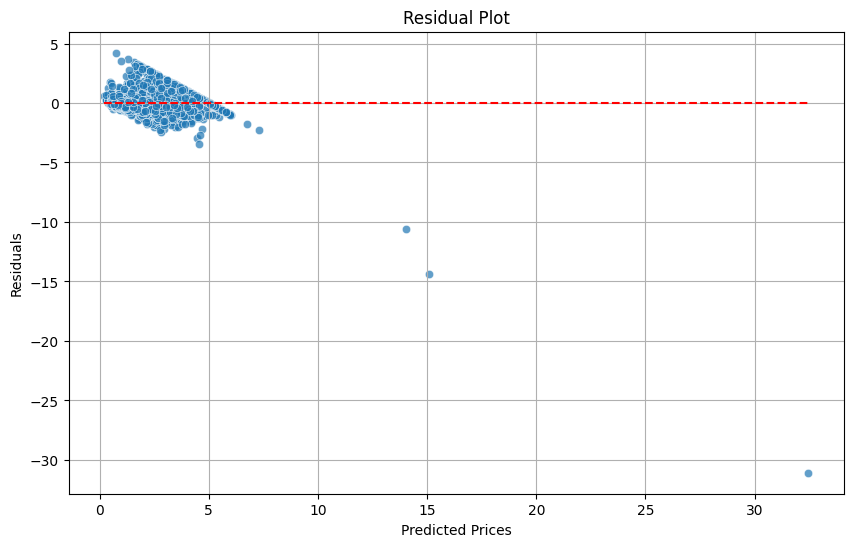

In [40]:
# Evaluate the regression model
test_loss, test_preds, test_trues = evaluate_regression(model, val_loader, criterion) # val_loader is used instead of test_loader only for lab convenience

# Calculate regression metrics
mae = mean_absolute_error(test_trues, test_preds)
mse = mean_squared_error(test_trues, test_preds)
rmse = np.sqrt(mse).item()

print(f"Test Loss (MSE): {test_loss:.4f}")
print(f"Test MAE: {mae:.4f}")
print(f"Test MSE: {mse:.4f}")
print(f"Test RMSE: {rmse:.4f}")

# Visualize predictions vs actual values using seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(x=test_trues, y=test_preds, alpha=0.7)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.ylim(0,10)
plt.grid(True)
plt.show()

# Visualize residuals using seaborn
residuals = test_trues - test_preds
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=30)
plt.xlabel("Residuals (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=test_preds, y=residuals, alpha=0.7)
plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.hlines(0, test_preds.min(), test_preds.max(), colors='red', linestyles='dashed')
plt.grid(True)
plt.show()

## Save & Load the model

In [41]:
# Save and load model
torch.save(model.state_dict(), 'regression_model.pth')

# Load model example
loaded_model = RegressionModel().to(device)
loaded_model.load_state_dict(torch.load('regression_model.pth'))

<All keys matched successfully>